# Рекуррентная нейронная сеть

Во многих случаях прогнозирование некоторого значения, например, завтрашней
цены на акцию или следующего слова в предложении зависит от того, какой была
цена сегодня или, например, вчера, а в случае текста от того, какие слова стояли
перед прогнозируемым словом.

**Рекуррентная нейронная сеть** (recurrent neural network, RNN) способна
учитывать предыдущие наблюдения или, говоря иначе, работать с
последовательностью (sequence) объектов.

## Основная идея
### Архитектура рекуррентной сети
Рассмотрим следующую задачу. Пусть нам известно, что завтрашняя $t+1$ цена на акцию компании зависит от ее стоимости сегодня $t$ и вчера $t-1.$

Посмотрим, какая архитектура нейронной сети позволит учитывать эти изменения.

![](https://drive.google.com/uc?export=view&id=1S3qmMHu77ZqAcM0lm0Ma3fBhu9RhUHx5)

Нейросеть будет состоять из трех слоев: входного $\mathbf x,$ скрытого $\mathbf h$ и выходного $\mathbf y,$ при этом
* веса и смещение между входным и скрытым слоями обозначим как $\mathbf W_{xh}$ и $\mathbf b_h$ соответственно;
* веса и смещение между скрытым и выходным слоем как $\mathbf W_{hy}$ и $\mathbf b_y;$ при этом
* в архитектуре рекуррентной нейронной сети появится еще один набор параметров $\mathbf W_{hh},$ который позволит учитывать предыдущие наблюдения при прогнозировании очередного значения.

Рассмотрим этот процесс пошагово. Будем подавать на вход сначала данные за
вчера $\mathbf x^{t-1},$ умножать на веса входного слоя $\mathbf W_{xh},$
добавлять смещение $\mathbf b_h$ и пропускать эти значения через функцию
активации $\varphi.$

Так мы получим значение скрытого слоя $\mathbf h^{t-1}.$

$$ \mathbf h^{t-1} = \varphi (\mathbf W_{xh} \cdot \mathbf x^{t-1} + \mathbf b_h) $$

Дальше в случае полносвязной архитектуры мы могли бы умножить на веса
$\mathbf W_{hy}$ и смещение $\mathbf b_y$ выходного слоя и получить
прогнозное значение $\hat{ \mathbf y}^t.$

$$ \hat{\mathbf y}^t = \mathbf W_{hy} \cdot \mathbf h^{t-1} + \mathbf b_y $$

Прогноз был бы сделан на сегодня, однако эта цена на акцию нам уже известна. Нам лишь хотелось бы, чтобы цена за вчера была учтена в сегодняшнем прогнозе на завтра.

Для этого одновременно подадим значение за сегодня $\mathbf x^{t}$ и значение скрытого слоя на предыдущем шаге $\mathbf h^{t-1}$ в аналогичную архитектуру

$$ \mathbf h^{t} = \varphi (\mathbf W_{xh} \cdot \mathbf x^{t} + \mathbf W_{hh}
\cdot \mathbf h^{t-1} + \mathbf b_h) $$

и уже после этого рассчитаем прогнозное значение на завтра $\hat{ \mathbf y }^{t+1}.$

$$ \hat{ \mathbf y}^{t+1} = \mathbf W_{hy} \cdot \mathbf h^{t} + \mathbf b_y $$
Таким образом, нам понадобится два «экземпляра» или две **ячейки** (cell) рекуррентной нейронной сети.
![](https://drive.google.com/uc?export=view&id=1eNN37TPKbBmX1_qPvfXXM_1eNTzoQLyy)

Заметим, что схема с петлей (loop), которую мы изобразили выше, как раз и указывает на возможность «развернуть» (unroll) эти ячейки.

Обратим внимание на два важных момента:
* параметры $\mathbf W_{xh}, \mathbf b_h, \mathbf W_{hh}, \mathbf W_{hy},
\mathbf b_y $ едины для всех шагов архитектуры;
* количество этих шагов может быть различным в зависимости от длины подаваемой последовательности (в коде мы будем разворачивать ячейки с помощью цикла for).

Вторая особенность позволяет подавать в нейросеть временные ряды, последовательности слов или, например, букв различной длины.

## Типы архитектуры
Выше мы показали, что одна ячейка RNN может выдавать выходное значение $\mathbf y^t$ или не выдавать, в зависимости от того, нужен ли нам прогноз на этом шаге или нет.

![](https://drive.google.com/uc?export=view&id=1n7iaupyxVGb_uhiBk9LeiJFuRuyYG70A)

Примечание. Обратите внимание, мы изменили нотацию, сделав ее более универсальной. Теперь вход и выход на шаге $t$ обозначаются как $\mathbf x^t$ и
$\hat{ \mathbf y}^{t}.$

Несложно представить, что в зависимости от того, сколько входов $T_x$ и выходов $T_y$ мы хотим «подключить» в течение одного разворачивания ячеек во времени, возможны различные типы архитектуры:
* **«много в один»** (many-to-one): подавая предложения, состоящие из различного количества слов $T_x>1$ мы можем предсказывать их тональность (sentiment analysis) $T_y=1;$
* **«один во много»** (one-to-many): подавая изображение на вход $T_x=1,$ мы хотели бы получить аннотацию, состоящую из нескольких слов (image captioning) $T_y>1;$
* **«много во много»** (many-to-many) предполагает два варианта:
  * подход $T_x = T_y$ можно использовать для распознавания
именованных сущностей (named entity recognition, NER), когда каждому слову ставится в соответствие тип сущности; или же
  * $T_x \neq T_y;$ в этом случае речь может идти, например, о машинном переводе (machine translation).


## Символьная языковая модель
Рекуррентная нейронная сеть может запоминать последовательности слов (wordlevel) естественного языка, а может запоминать последовательности символов (character-level или character-based). Во втором случае говорят о символьной
языковой модели **Текст, выделенный полужирным шрифтом** (character-level language model).

Поскольку на вход и на выход подается различное количество символов, речь идет об архитектуре many-to-many

### Подготовка данных
Будем обучать модель на рассказах Артура Конан Дойля о Шерлоке Холмсе.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open('/content/sholmes.txt') as f:
  data = f.read()

Составим список уникальных символов (также называемый вокабуляром, хотя последний термин относится скорее к уникальным словам).

In [3]:
chars = sorted(list(set(data)))

Запомним количество уникальных символов.

In [4]:
chars_size = len(chars)
chars_size

54

Создадим два словаря. Первый будет находить индекс символа по ключу,
содержащему этот символ. Второй, наоборот, символ по индексу.

In [5]:
char_to_ix = {ch:i for i, ch in enumerate(chars)}
ix_to_char = {i:ch for i, ch in enumerate(chars)}

char_to_ix['e'], ix_to_char[32]

(32, 'e')

## Архитектура сети
На каждом шаге мы подаем по одному символу $\mathbf x^t.$ Каждый символ
закодирован в one-hot вектор размерностью 54 x 1 таким образом, чтобы единица
соответствовала порядку символа в перечне уникальных символов.

Например, символ `e` можно закодировать так:

In [6]:
a_vector = np.zeros((chars_size,1))
a_vector[32] = 1

Определимся с количеством нейронов (каждого) скрытого слоя, длиной
последовательности (в этом примере мы зафиксируем подаваемое за один раз
количество символов) и скоростью обучения.

In [7]:
hidden_size = 100
seq_length = 15
learning_rate = .01

На выходе меткой $\hat{\mathbf y}^t$ будет та же последовательность, сдвинутая на
один символ вправо. В самом деле, если последовательность символов
представляет собой слово ‘hello’, то нам бы хотелось, чтобы на основе буквы ‘h’ с
наибольшей вероятностью прогнозировалась буква ‘e’.

### Инициализация весов
Ранее мы уже объяснили, почему не стоит инициализировать веса нулевыми
значениями.

Помимо этого возможна инициализация весов небольшими случайными
значениями, взятыми из равномерного распределения

$$ \mathbf W_{\text{random}} \sim \mathcal{U} \left[ -\frac{1}{\sqrt{n}} ; \frac{1}
{\sqrt{n}} \right], $$

где $n$ — количество нейронов предыдущего слоя (в случае входного слоя речь
идет о количестве признаков), или стандартного нормального распределения с
уменьшенной дисперсией

$$ \mathbf W_{\text{random}} \sim \mathcal{N} \left( 0; \frac{1}{1000} \right) $$

Еще одним подходом является **инициализация Ксавье**, также называемая
**инициализацией Глоро**, по имени автора Ксавье Глоро (Xavier Glorot). В
частности, предлагается также использовать равномерное

$$ \mathbf W_{\text{Xavier}} \sim \mathcal{U} \left[ -\sqrt{ \left( \frac{6}
{(n_{\text{in}} + n_{\text{out}})} \right) } ; \sqrt{ \left( \frac{6}{(n_{\text{in}} +
n_{\text{out}})} \right) } \right] $$

или нормальное

$$ \mathbf W_{\text{Xavier}} \sim \mathcal{N} \left( 0; \sqrt{ \frac{2}{(n_{\text{in}}
+ n_{\text{out}}) }} \right) $$

распределения, где $n_{\text{in}}$ — количество нейронов предыдущего слоя (или
признаков в случае входного слоя), а $n_{\text{out}}$ — количество нейронов
последующего. Обоснование подхода (https://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf) выходит за рамки этого занятия.

In [8]:
np.random.seed(33)

n_in, n_out = chars_size, hidden_size
stddev = np.sqrt(2 / (n_in + n_out))
Wxh = np.random.normal(scale = stddev, size=(hidden_size, chars_size))

n_in, n_out = hidden_size, hidden_size
stddev = np.sqrt(2 / (n_in + n_out))
Whh = np.random.normal(scale = stddev, size=(hidden_size, hidden_size))

n_in, n_out = hidden_size, chars_size
stddev = np.sqrt(2 / (n_in + n_out))
Why = np.random.normal(scale = stddev, size=(chars_size, hidden_size))

bh = np.zeros((hidden_size, 1))
by = np.zeros((chars_size, 1))

## Функции активации
### Функция гиперболического тангенса
Функцией активации будет **функция гиперболического тангенса** (hyperbolic
tangent function, tanh), которая приводит значения к диапазону от $-1$ до $1.$

$$ \tanh(x) = \frac{e^x-e^{-x}}{e^x+e^{-x}} $$

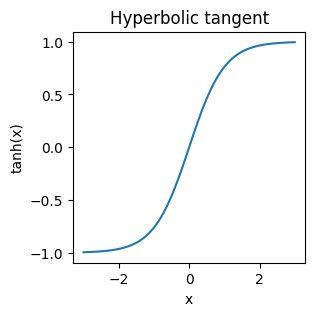

In [9]:
plt.figure(figsize=(3,3))
x = np.linspace(-3, 3, 100)
plt.plot(x, (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x)))
plt.title('Hyperbolic tangent')
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.show()

Далее будем использовать функцию **np.tanh()**.
### Функция softmax
Кроме этого, на выходе мы будем подавать значения $\hat{\mathbf y}^t$ в функцию
softmax, ожидаемо работающую в паре с функцией кросс-энтропии.

In [10]:
# используем вычислительно устойчивый вариант функции
def softmax(x):
  x = x - np.max(x)
  p = np.exp(x)
  return p / np.sum(p)

### Прямое распространение
Предположим, что последовательность состоит из символов, образующих слово
hello. В этом случае мы развернем четыре скрытых ячейки.
![](https://drive.google.com/uc?export=view&id=1z1WLRFdK85pk_HmgKawrcVQqAj7OO__k)

Примечание. Смещения $\mathbf b_h$ и $\mathbf b_y$ не показаны.
С точки зрения вероятностей речь опять же идет о том, чтобы при подаче на вход,
например, буквы ‘h’ с наибольшей вероятностью прогнозировалась буква ‘e’.

![](https://drive.google.com/uc?export=view&id=1VqEvdceMKqV4O9rd4Rizl-IneQlz1bKb)

Приведем формулу расчета значений скрытых слоев

$$ \mathbf h^t = \tanh ( \mathbf W_{xh} \mathbf x^t + \mathbf W_{hh} \mathbf h^{t-1}
+ \mathbf b_h) $$

и выходных значений

$$ \hat{\mathbf y}^t = \mathbf W_{hy} h^t + \mathbf{b}_y $$

Технически в процессе обучения нейросеть будет запоминать текст «кусками» по
15 символов в каждом. Для этого вначале нам необходимо составить список
порядковых номеров символов очередной последовательности.



В целом это реализовано в коде ниже.

`inputs = [char_to_ix[ch] for ch in data[p:p+seq_length]]`
`targets = [char_to_ix[ch] for ch in data[p+1:p+seq_length+1]]`

Опять же целевая последовательность совпадает с входной, но со сдвигом на один символ вперед.

Переменная `p` выполняет роль указателя (pointer). Вначале значение указателя равно нулю `p=0`, а затем после каждой эпохи обучения увеличивается на длину последовательности.

`p += seq_length`

Создадим словари, в которые для каждой последовательности будем записывать значения входного $\mathbf x^t$ и скрытого $\mathbf h^t$ слоев, логитов $\hat{\mathbf y}^t$ и вероятностей $ \mathbf p^t.$

`xs, hs, ys, ps = {}, {}, {}, {}`

Первое значение скрытого слоя будет нулевым.

`hs[-1] = np.zeros((hidden_size, 1))`

В цикле выполним прямое распространение.

```
for t in range(len(inputs)):
# создадим one-hot вектор символа,
  xs[t] = np.zeros((chars_size,1))
  xs[t][inputs[t]] = 1
# найдем значение скрытого слоя,
  hs[t] = np.tanh(np.dot(Wxh, xs[t]) + np.dot(Whh, hs[t-1]) + bh)
# значение выходного слоя
  ys[t] = np.dot(Why, hs[t]) + by
# и вероятности
  ps[t] = softmax(ys[t])
```





### Кросс-энтропия

Кросс-энтропию на шаге $t$ можно рассчитать по формуле

$$ \mathcal{L}^t(\mathbf y^{t}, \mathbf p^{t}) = -\sum_{i=1}^C y^t_i \log p^t_i, $$

где $C$ — количество классов, т.е. уникальных символов.

Обозначим «правильный» класс (символ) $C_i$ через $i = j.$ Поскольку для всех
остальных классов $i \neq j,$ $y_i = 0,$ то формулу можно упростить

$$ \mathcal{L}^t(\mathbf y^{t}, \mathbf p^{t}) = -\log p^t_i $$

Общая кросс-энтропия является суммой значений кросс энтропии на каждом из $t$
шагов последовательности длины $T$.

$$ \mathcal{L} = \sum_{t=1}^{T} \mathcal{L}^t(\mathbf y^{t}, \mathbf p^{t}) $$



```
# будем аккумулировать ошибку в цикле прямого распространения
# небольшая константа добавлена для вычислительной устойчивости
loss += -np.log(ps[t][targets[t], 0] + 1e-10)
```



### Обратное распространение
Перейдем к обратному распространению. Рассмотрим поток градиентов на $t=1$ шаге.
![](https://drive.google.com/uc?export=view&id=1WvHgwOhs9KnWxXGRlwgm-DAFEpPxNJAi)

#### Обратное распространение ошибки во времени
В примере выше градиент рассчитывается от шага $t=4$ к шагу $t=1$ на каждый из
скрытых слоев, а также на каждый параметр $\mathbf W_{hy},$ $\mathbf b_y,$
$\mathbf W_{hh},$ $\mathbf b_h$ и $\mathbf W_{xh}.$

Такое распространение ошибки называется **обратным распространением ошибки во времени** (backpropagation through time, BPTT).
Более того, поскольку мы зафиксировали длину последовательности через параметр `seq_length` речь идет о truncated BPTT.

Дополнительно заметим, что поскольку параметры модели используются $t$ раз, то
значения их градиентов суммируются на каждом из шагов обратного
распространения.

```
## подготовим массивы для расчета частных производных параметров
dWxh, dWhh, dWhy = np.zeros_like(Wxh), np.zeros_like(Whh),
np.zeros_like(Why)
dbh, dby = np.zeros_like(bh), np.zeros_like(by)
# и скрытого слоя на шаге t+1
dhnext = np.zeros_like(hs[0])
```
```
# ошибку будем распространять от последнего шага к первому
for t in reversed(range(len(inputs))):
```
Перейдем к расчету частных производных.

### Производная кросс-энтропии и softmax

Начнем с производной softmax. Вспомним, что softmax является вектор-функцией,
преобразующей логиты $\hat{ \mathbf y}$ в вероятности $\mathbf p$

$$ \text{softmax} : \mathbb{R}^n \rightarrow \mathbb{R}^n, $$

где каждую координату $p_i$ можно найти через

$$ p_i = \frac{e^{\hat{y}_i}}{\sum^n_{l=1} e^{\hat{y}_l} }, \quad \forall i = 1, \ldots, n
$$

Все возможные частные производные такой вектор-функции образуют матрицу
Якоби $J_{n \times n}$ (Jacobian matrix).

$$ J = \begin{pmatrix} \frac{ \partial p_1}{\partial \hat{y}_1} & \frac{ \partial p_1}
{\partial \hat{y}_2} & \ldots & \frac{ \partial p_1}{\partial \hat{y}_n} \\ \frac{ \partial
p_2}{\partial \hat{y}_1} & \frac{ \partial p_2}{\partial \hat{y}_2} & \ldots & \frac{
\partial p_2}{\partial \hat{y}_n} \\ \vdots & \vdots & \ddots & \vdots \\ \frac{\partial p_n}
{\partial \hat{y}_1} & \frac{\partial p_n}{\partial \hat{y}_2} & \ldots & \frac{\partial
p_n}{\partial \hat{y}_n} \end{pmatrix} $$

Найдем частные производные логарифма данной функции. Тогда по правилу производной сложной функции

$$ \frac{\partial}{\partial \hat{y}_j} \log p_i = \frac{1}{p_i} \cdot \frac{\partial p_i}
{\partial \hat{y}_j} $$

Выразим $\frac{\partial p_i}{\partial \hat{y}_j},$

$$ \frac{\partial p_i}{\partial \hat{y}_j} = p_i \cdot \frac{\partial}{\partial \hat{y}_j}
\log p_i, $$

что и будет частными производными $J.$ Возьмем логарифм от $p_i.$

$$ \log p_i = \log \left( \frac{e^{\hat{y}_i}}{\sum^n_{l=1} e^{\hat{y}_l} } \right) =
\hat{y}_i-\log \left( \sum^n_{l=1} e^{\hat{y}_l} \right) $$

Найдем частные производные разницы.

$$ \frac{\partial}{\partial \hat{y}_j} \log p_i = \frac{\partial \hat{y}_i}{\partial
\hat{y}_j}-\frac{\partial}{\partial \hat{y}_j} \log \left( \sum^n_{l=1} e^{\hat{y}_l}
\right) $$

Заметим, что

$$ \frac{\partial \hat{y}_i}{\partial \hat{y}_j} = \begin{cases} 1, & \text{если } i=j \\ 0,
& \text{если } i \neq j, \end{cases} $$

что можно записать через индикатор $ \mathbf{1}\{ i=j \}. $ Тогда,

$$ \frac{\partial}{\partial \hat{y}_j} \log p_i = \mathbf{1}\{ i=j \}-\frac{\partial}{\partial
\hat{y}_j} \log \left( \sum^n_{l=1} e^{\hat{y}_l} \right) $$

Воспользовавшись производной логарифма $ \frac{d}{dx} \log x = \frac{1}{x} $ и
правилом производной сложной функции,

$$ \frac{\partial}{\partial \hat{y}_j} \log p_i = \mathbf{1}\{ i=j \}-\frac{1}
{\sum^n_{l=1} e^{\hat{y}_l}} \cdot \left( \frac{\partial}{\partial \hat{y}_j}
\sum^n_{l=1} e^{\hat{y}_l} \right)$$

Наконец,

$$ \frac{\partial}{\partial \hat{y}_j} \sum^n_{l=1} e^{\hat{y}_l} = \frac{\partial}
{\partial \hat{y}_j} [ e^{\hat{y}_1} + e^{\hat{y}_2} + \ldots + e^{\hat{y}_j} + \ldots +
e^{\hat{y}_n} ] = \frac{\partial}{\partial \hat{y}_j} [ e^{\hat{y}_j} ] = e^{\hat{y}_j} $$

Как следствие,

$$ \frac{\partial}{\partial \hat{y}_j} \log p_i = \mathbf{1}\{ i=j \}-\frac{e^{\hat{y}_j}}
{\sum^n_{l=1} e^{\hat{y}_l}} = \mathbf{1}\{ i=j \}-p_j $$

Подставим результаты в выражение для $ \frac{\partial p_i}{\partial \hat{y}_j} $

$$ \frac{\partial p_i}{\partial \hat{y}_j} = p_i \cdot \frac{\partial}{\partial \hat{y}_j}
\log p_i = p_i \cdot \mathbf{1}\{ i=j \}-p_j $$

Для $n=4$ получим,

$$ J = \begin{pmatrix} p_1 \cdot (1-p_1) & -p_1 \cdot p_2 & -p_1 \cdot p_3 & -p_1 \cdot
p_4 \\ -p_2 \cdot p_1 & p_2 \cdot (1-p_2) & -p_2 \cdot p_3 & -p_2 \cdot p_4 \\ -p_3 \cdot
p_1 & -p_3 \cdot p_2 & p_3 \cdot (1-p_3) & -p_3 \cdot p_4 \\ -p_4 \cdot p_1 & -p_4
\cdot p_2 & -p_4 \cdot p_3 & p_4 \cdot (1-p_4) \end{pmatrix} $$
Еще раз приведем функцию кросс-энтропии
$$ \mathcal{L}(\mathbf y, \mathbf p) = -\sum_{i=1}^C y_i \; \log p_i $$

Найдем $ \frac{\partial \mathcal L}{\partial \hat{y}_j}, $ подставляя полученные выше результаты.

$$ \begin{align} \frac{\partial \mathcal L}{\partial \hat{y}_j} &= -\frac{\partial}{\partial
\hat{y}_j} \sum^C_{i=1} y_i \cdot \log p_i = -\sum^C_{i=1} y_i \cdot \frac{\partial}
{\partial \hat{y}_j} \log p_i \\ &= -\sum^C_{i=1} \frac{y_i}{p_i} \cdot \frac{\partial
p_i}{\partial \hat{y}_j} \\ &= -\sum^C_{i=1} \frac{y_i}{p_i} \cdot p_i \cdot
(\mathbf{1}\{ i=j \}-p_j) = -\sum^C_{i=1} y_i \cdot (\mathbf{1}\{ i=j \}-p_j) \\ &=
\sum^C_{i=1} y_i \cdot p_j-\sum^C_{i=1} y_i \cdot (\mathbf{1}\{ i=j \}-p_j)
\end{align} $$

Поскольку индикаторная функция равна нулю везде, кроме $i=j,$

$$ \begin{align} \frac{\partial \mathcal L}{\partial \hat{y}_j} &= \sum^C_{i=1} y_i
\cdot p_j-y_j \\ &= p_j \cdot \sum^C_{i=1} y_i-y_j \\ &= p_j-y_j, \end{align} $$

в силу того, что $ \sum^C_{i=1} y_i = 1.$ В векторной нотации,

$$ \frac{\partial \mathcal{L}}{\partial \hat{\mathbf y}} = \mathbf p-\mathbf y $$

При этом, поскольку $ \mathbf y $ — это one-hot вектор, то $ \frac{\partial \mathcal
L}{\partial \hat{y}_i} $ можно записать так

$$ \frac{\partial \mathcal L}{\partial \hat{y}_i} = \begin{cases} p_i & \quad \text{если }
i \neq j \\ p_i-1 & \quad \text{если } i=j \end{cases} $$



```
dy = np.copy(ps[t])
dy[targets[t]] -= 1
```




#### Распространение ошибки на $\mathbf W_{hy}$ и $\mathbf b_y$
По правилу производной сложной функции

$$ \frac{\partial \mathcal L^t}{\partial \mathbf W_{hy}} = \frac{\partial \mathcal L^t}
{\partial \hat{\mathbf y}^t} \cdot \frac{\partial \hat{\mathbf y}^t}{\partial \mathbf
W_{hy}} $$

Продифференцируем $\hat{\mathbf y}^t = \mathbf W_{hy} \mathbf h^t+ \mathbf b, $
где $\mathbf h^t$ — значение ячейки текущего скрытого слоя, относительно
$\mathbf W_{hy}.$

$$ \frac{\partial \hat{\mathbf y}^t}{\partial \mathbf W_{hy}} = \mathbf h^t $$

Тогда,

$$ \frac{\partial \mathcal L^t}{\partial \mathbf W_{hy}} = \frac{\partial \mathcal L^t}
{\partial \hat{\mathbf y}^t} \mathbf h^t $$

Аналогично,

$$ \frac{\partial \hat{\mathbf y}^t}{\partial \mathbf b_y} = 1, \quad \frac{\partial
\mathcal L^t}{\partial \mathbf b_y} = \frac{\partial \mathcal L^t}{\partial \hat{\mathbf
y}^t} $$

Общий градиент для всех $t$ шагов можно найти через

$$ \frac{\partial \mathcal L}{\partial \mathbf W_{hy}} = \sum_{t=T}^1 \frac{\partial
\mathcal L^t}{\partial \hat{\mathbf y}^t} \mathbf h^t, \quad \frac{\partial \mathcal L}
{\partial \mathbf b_y} = \sum_{t=T}^1 \frac{\partial \mathcal L^t}{\partial \hat{\mathbf
y}^t}, $$

где нотация $\sum_{t=T}^{1}$ указывает на то, что мы начинаем с последнего шага $T$ и заканчиваем первым.

```
dWhy += np.dot(dy, hs[t].T)
dby += dy
```
#### Распространение ошибки на $\mathbf h^t$
Частные производные относительно скрытого слоя $ \mathbf h^t$ определяются
градиентом, «проходящим» через текущий выходной слой $ \partial \hat{ \mathbf y
}^t $ и градиентом, «проходящим» через предыдущий скрытый слой $\mathbf
h^{t+1}.$

$$ \frac{ \partial \mathcal L }{\partial \mathbf h^t} = \frac{\partial \mathcal L^t}{\partial
\hat{\mathbf y}^t} \cdot \frac{\partial \hat{\mathbf y}^t}{\partial \mathbf h^t} +
\frac{\partial \mathcal L^{t+1} }{\partial \mathbf h^{t+1}} \cdot \frac{\partial \mathbf
h^{t+1}}{\partial \mathbf h^t} $$

Вначале займемся градиентом из текущего выходного слоя.

$$ \frac{\partial \hat{\mathbf y}^t}{\partial \mathbf h^t} = \mathbf W_{hy} $$

$$ \frac{\partial \mathcal L^t}{\partial \mathbf h^t} = \frac{\partial \mathcal L^t}{\partial
\hat{\mathbf y}^t} \cdot \frac{\partial \hat{\mathbf y}^t}{\partial \mathbf h^t} =
\frac{\partial \mathcal L^t}{\partial \hat{\mathbf y}} \cdot \mathbf W_{hy} $$

Теперь займемся градиентом из предыдущего выходного слоя. Поскольку на каждом шаге $t$

$$ \mathbf h^t = \tanh ( \mathbf W_{xh} \mathbf x^t + \mathbf W_{hh} \mathbf h^{t-1}
+ \mathbf b_h) $$

в первую очередь найдем производную $\frac{\partial \tanh(\mathbf h^t)} {\partial
\mathbf h^t}.$

$$ \begin{gather} \begin{array}{rl} \frac{d}{dx} \left( \frac{e^x-e^{-x}}{e^x+e^{-x}}
\right) &=& \frac{e^x-e^{-x}}{(e^x+e^{-x})^2} d(e^x-e^{-x})-\frac{e^x-e^{-x}}
{(e^x+e^{-x})^2} d(e^x+e^{-x}) \\ &=& \frac{(e^x+e^{-x})(e^x+e^{-x})}{(e^x+e^{-
x})^2}-\frac{(e^x-e^{-x})(e^x-e^{-x})}{(e^x+e^{-x})^2} \\ &=& \frac{(e^x+e^{-x})^2-
(e^x-e^{-x})^2}{(e^x+e^{-x})^2} \\ &=& 1-\left( \frac{e^x-e^{-x}}{e^x+e^{-x}}
\right)^2 = 1-\tanh(x)^2 \end{array} \end{gather} $$

После этого, используя правило производной сложной функции, найдем $ \frac{
\partial \mathcal L^{t+1} }{\partial \mathbf h^t} .$

$$ \begin{gather} \begin{array}{rl} \frac{\partial \mathcal L^{t+1} }{\partial \mathbf
h^t} &=& \frac{\partial \mathcal L^{t+1} }{\partial \mathbf h^{t+1}} \cdot \frac{\partial
\mathbf h^{t+1}}{\partial \mathbf h^t} \\ &=& \frac{\partial \mathcal L^{t+1} }{\partial
\mathbf h^{t+1}} (1-(\mathbf h^t)^2) \mathbf W_{hh} \end{array} \end{gather} $$

Соберем все вместе.

$$ \frac{ \partial \mathcal L }{\partial \mathbf h^t} = \frac{\partial \mathcal L^t}{\partial
\hat{\mathbf y}^t} \cdot \mathbf W_{hy} + \frac{\partial \mathcal L^{t+1} }{\partial
\mathbf h^{t+1}} (1-(\mathbf h^t)^2) \mathbf W_{hh} $$

В коде с учетом матричного умножения получим.

```
dh = np.dot(Why.T, dy) + dhnext
dhraw = (1 - hs[t] * hs[t]) * dh
dhnext = np.dot(Whh.T, dhraw)
```
При этом еще раз скажем, что на первом с конца шаге $\mathbf h^T$ значением `dhnext`


будет нулевой вектор $\mathbf 0.$

Распространение ошибки на $\mathbf W_{xh}, \mathbf W_{hh}$ и $\mathbf b_h$

Веса $\mathbf W_{xh}, \mathbf W_{hh}$ и $\mathbf b_h$ используются на каждом
из шагов прямого распространения.

Как следствие, поскольку, например, изменение $\mathbf W_{xh}$ влияет на
каждый $\mathbf h^t$ и в совокупности эти значения влияют на $ \hat{\mathbf y}^t $
и затем на $\mathcal L^t,$ то для расчета частных производных вначале необходимо
распространить ошибку на каждую из ячеек $\mathbf h^t.$

$$ \frac{\partial \mathcal L}{\partial \mathbf W_{xh}} = \sum_{t=T}^{1} \frac{\partial
\mathcal L^t}{\partial \mathbf h^t} \cdot \frac{\partial \mathbf h^t}{\partial \mathbf
W_{xh}} $$

Аналогичное рассуждение можно провести для $ \mathbf W_{hh} $ и $\mathbf b_h.$

Остается найти частные производные от скрытого слоя $\mathbf h^t$ до параметров
модели

$$ \begin{align} \frac{\partial \mathbf h^t}{\partial \mathbf W_{xh}} & = (1-(\mathbf
h^t)^2)\: \mathbf x^t \\ \frac{\partial \mathbf h^t}{\partial \mathbf W_{hh}} & = (1-
(\mathbf h^t)^2) \: \mathbf h^{t-1} \\ \frac{\partial \mathbf h^t}{\partial \mathbf b_{h}}
& = (1-(\mathbf h^t)^2) \end{align} $$

В коде это можно выразить следующим образом.

```
dWxh += np.dot(dhraw, xs[t].T)
dWhh += np.dot(dhraw, hs[t-1].T)
dbh += dhraw
```
Приведем весь код обратного распространения.
```
dhnext = np.zeros_like(hs[0])

for t in reversed(range(len(inputs))):
  dy = np.copy(ps[t])
  dy[targets[t]] -= 1
  dWhy += np.dot(dy, hs[t].T)
  dby += dy
  dh = np.dot(Why.T, dy) + dhnext
  dhraw = (1 - hs[t] * hs[t]) * dh
  dWxh += np.dot(dhraw, xs[t].T)
  dWhh += np.dot(dhraw, hs[t-1].T)
  dbh += dhraw
  dhnext = np.dot(Whh.T, dhraw)
```




#### Взрыв и затухание градиента
Предположим без ограничения общности, что вместо функции гиперболического
тангенса мы используем линейную активацию $g(\mathbf z) = \mathbf z.$ В этом
случае распространение ошибки от одного скрытого слоя до другого примет вид

$$ \frac{\partial \mathbf h^{t+1}}{\partial \mathbf h^t} = \mathbf W_{hh} $$

Таким образом, распространение ошибки на $\mathbf h^1$ можно найти через

$$ \begin{split} \frac{\partial \mathcal L}{\partial \mathbf h^1} &=& \frac{\partial
\mathcal L}{\partial \hat{\mathbf y}} \cdot \frac{\partial \hat{\mathbf y}}{\partial
\mathbf h^4} \cdot \frac{\partial \mathbf h^4}{\partial \mathbf h^3} \cdot \frac{\partial
\mathbf h^3}{\partial \mathbf h^2} \cdot \frac{\partial \mathbf h^2}{\partial \mathbf
h^1} \\ &=& \frac{\partial \mathcal L}{\partial \hat{\mathbf y}} \cdot \frac{\partial
\hat{\mathbf y}}{\partial \mathbf h^4} \cdot \mathbf W_{hh} \cdot \mathbf W_{hh}
\cdot \mathbf W_{hh} \end{split}$$

При большом количестве скрытых слоев в случае если $ \mathbf W_{hh} $ больше
единицы, градиент может «взорваться» (explode) и это дестабилизирует процесс
обучения. Наоборот, если $ \mathbf W_{hh} $ меньше единицы, он может
«затухнуть» (vanish), и веса перестанут обновляться.

Проблему взрыва градиента можно решить, ограничив значения градиента
минимальным и максимальным значением (gradient value clipping)


```
for dparam in [dWxh, dWhh, dWhy, dbh, dby]:
  np.clip(dparam, -1, 1, out=dparam)
```
Проблему затухания градиента можно скорректировать (https://arxiv.org/pdf/1504.00941) через инициализацию
весов единичной матрицей (identity RNN) и использованием ReLU в качестве функции активации или использованием архитектуры LSTM.

#### Запоминание непосредственного прошлого

Кроме этого заметим, что RNN способна запомнить только непосредственное прошлое (immediate past).
![](https://drive.google.com/uc?export=view&id=1pOxm6DJSKleafcEDIGBYLZ8asMsUitRI)

Чем больше длина последовательности, тем меньший вес имеют первые ее элементы, и тем меньше они влияют на уровень ошибки.
#### Обновление параметров
Обновим параметры модели.

```
Wxh -= learning_rate * dWxh
Whh -= learning_rate * dWhh
Why -= learning_rate * dWhy
bh -= learning_rate * dbh
by -= learning_rate * dby
```
### Расчет уровня ошибки
Поскольку уровень ошибки рассчитывается после «прочтения» каждой
последовательности символов, его значение может сильно колебаться. Имеет смысл применить экспоненциальное сглаживание.

```
# зададим уровень ошибки перед началом обучения
smooth_loss = -np.log(1.0 / chars_size) * seq_length
# в процессе обучения будем обновлять уровень ошибки,
# отдавая предпочтение предыдущим значениям
smooth_loss = smooth_loss * 0.999 + loss * 0.001
```



### Генерирование текста
Периодчески в процессе обучения будем просить рекуррентную нейросеть
генерировать новый текст. Для этого инициализируем $\mathbf h^0$ и $\mathbf x^0$
последним (на данный момент) значением скрытого слоя и первым символом
текущей обучающей последовательности соответственно.
```
h = hs[len(inputs)-1]
x = np.zeros((chars_size, 1))
x[inputs[0]] = 1
```
Кроме этого объявим список, в который будем помещать сгенерированные
символы.

```
ixes = []
```
Далее в цикле, равном длине генерируемой последовательности, рассчитаем
вероятностное распределение следующего символа и выберем из списка
уникальных символов новый символ с учетом этого распределения.

```
# пусть новый текст состоит из ста символов
for t in range(100):
  # рассчитаем вероятностное распределение нового символа,
  h = np.tanh(np.dot(Wxh, x) + np.dot(Whh, h) + bh)
  y = np.dot(Why, h) + by
  probs = softmax(y)

  # выберем этот символ,
  ix = np.random.choice(range(chars_size), p=probs.ravel())
  # закодируем его и
  x = np.zeros((chars_size, 1))
  x[ix] = 1
  # поместим в список
  ixes.append(ix)
```
Остается вывести получившийся текст.

```
txt = ''.join(ix_to_char[ix] for ix in ixes)
print(txt)
print('-----')
```








### Обучение модели
Приведем код цикла обучения модели и результат обучения.

In [11]:
p = 0
# зададим уровень ошибки перед началом обучения
smooth_loss = -np.log(1.0 / chars_size) * seq_length

In [12]:
for n in range(int(len(data)/seq_length)):

  if n == 0 or p + seq_length + 1 >= len(data):
    h_prev = np.zeros((hidden_size, 1))
    p = 0

  inputs = [char_to_ix[ch] for ch in data[p:p+seq_length]]
  targets = [char_to_ix[ch] for ch in data[p+1:p+seq_length+1]]

  xs, hs, ys, ps = {}, {}, {}, {}

  hs[-1] = np.copy(h_prev)
  loss = 0

  for t in range(len(inputs)):
    xs[t] = np.zeros((chars_size,1))
    xs[t][inputs[t]] = 1
    hs[t] = np.tanh(np.dot(Wxh, xs[t]) + np.dot(Whh, hs[t-1]) + bh)
    ys[t] = np.dot(Why, hs[t]) + by
    ps[t] = softmax(ys[t])
    loss += -np.log(ps[t][targets[t], 0] + 1e-10)

  dWxh, dWhh, dWhy = np.zeros_like(Wxh), np.zeros_like(Whh), np.zeros_like(Why)
  dbh, dby = np.zeros_like(bh), np.zeros_like(by)
  dhnext = np.zeros_like(hs[0])

  for t in reversed(range(len(inputs))):
    dy = np.copy(ps[t])
    dy[targets[t]] -= 1
    dWhy += np.dot(dy, hs[t].T)
    dby += dy
    dh = np.dot(Why.T, dy) + dhnext
    dhraw = (1 - hs[t] * hs[t]) * dh
    dWxh += np.dot(dhraw, xs[t].T)
    dWhh += np.dot(dhraw, hs[t-1].T)
    dbh += dhraw
    dhnext = np.dot(Whh.T, dhraw)

  for dparam in [dWxh, dWhh, dWhy, dbh, dby]:
    np.clip(dparam, -1, 1, out=dparam)

  Wxh -= learning_rate * dWxh
  Whh -= learning_rate * dWhh
  Why -= learning_rate * dWhy
  bh -= learning_rate * dbh
  by -= learning_rate * dby

  p += seq_length

  smooth_loss = smooth_loss * 0.999 + loss * 0.001

  if n % 20000 == 0:

    print('epoch %d, loss: %f' % (n, smooth_loss))
    h = hs[len(inputs)-1]
    x = np.zeros((chars_size, 1))
    x[inputs[0]] = 1
    ixes = []

    for t in range(100):
      h = np.tanh(np.dot(Wxh, x) + np.dot(Whh, h) + bh)
      y = np.dot(Why, h) + by
      probs = softmax(y)

      ix = np.random.choice(range(chars_size), p=probs.ravel())
      x = np.zeros((chars_size, 1))
      x[ix] = 1
      ixes.append(ix)

    txt = ''.join(ix_to_char[ix] for ix in ixes)
    print(txt)
    print('-----')

epoch 0, loss: 59.837298
y1bm*ube.dn)hq]z!.h7zs2"?*ogx3,2 "qb8?s(su?p*ag`is."[l4h`u5!wv;z]?6ts zf?5`*5to[n1]],&h[jmoij!)z8hj6
-----
epoch 20000, loss: 34.225128
mis eloteds.
"ti'ned? hedeverse sters.
"if inew liow she ofe. herse's hro, goes wef eiss indweal
che
-----
epoch 40000, loss: 32.534210
miss ble, theation he thes spimidings
this me wipliuncs broves towe sive us compide more
she the min
-----
epoch 60000, loss: 32.153032
u aplidctrasuagrspan, bring-taggatley. oul? well that al
and that iveary that is the say. agd am awf
-----
epoch 80000, loss: 31.535463
-h4 rame on tur& lanearl, credod
belled a pexed  re burner-the si2et ere butteredly wy the buere by 
-----
epoch 100000, loss: 31.079432
n. the that mowe thought they had 1thing that i jess. in throuss itsarrast of dotints
was the this s
-----
epoch 120000, loss: 31.131806
fore
amorging midveger of his
that these filvem. 3implet'ard rearct at out been tr4inder a for ament
-----
epoch 140000, loss: 30.102242
it from traight
had 

Список литературы

Karpathy A., The Unreasonable Effectiveness of Recurrent Neural
Networks (https://karpathy.github.io/2015/05/21/rnn-effectiveness/), 2015.
